# Five-Fold Cross-Validation of the Classical Models

This notebook evaluates the SVM and Logistic Regression classifiers using stratified five-fold cross-validation. Only the original English training subset is used; the validation and final test subsets remain excluded. TF-IDF is fitted again inside every fold to prevent information leakage.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'Models').exists() and (candidate / 'Dataset source').exists():
            return candidate
    raise FileNotFoundError('Could not locate the project root.')


BASE_DIR = find_project_root(Path.cwd())
DATASET_PATH = BASE_DIR / 'Dataset source' / 'training' / 'Dataset_SMS_clean.csv'
RESULT_DIR = BASE_DIR / 'results' / 'cross_validation'
FOLD_RESULTS_PATH = RESULT_DIR / 'classical_models_fold_results.csv'
SUMMARY_PATH = RESULT_DIR / 'classical_models_summary.csv'
FOLD_F1_FIGURE_PATH = BASE_DIR / 'figure' / 'figure_5_1_classical_models_fold_f1.png'
RECALL_FIGURE_PATH = BASE_DIR / 'figure' / 'figure_5_2_classical_models_fold_recall.png'

RANDOM_STATE = 42
HOLDOUT_SIZE = 0.20
N_SPLITS = 5

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FOLD_F1_FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f'Project root: {BASE_DIR}')
print(f'Dataset: {DATASET_PATH}')

Project root: D:\Project\Leeds\Msc Project
Dataset: D:\Project\Leeds\Msc Project\Dataset source\training\Dataset_SMS_clean.csv


In [2]:
# Recreate the original 80% English training subset. The 20% holdout is not used in CV.
data = pd.read_csv(DATASET_PATH, encoding='utf-8-sig')
data = data.dropna(subset=['Category', 'Message']).copy()
data['Category'] = data['Category'].astype(str).str.strip().str.lower()
data['Message'] = data['Message'].astype(str).str.strip()
data = data[data['Category'].isin(['ham', 'spam'])]
data = data[data['Message'].ne('')].reset_index(drop=True)

development_messages, holdout_messages, development_labels, holdout_labels = train_test_split(
    data['Message'],
    data['Category'],
    test_size=HOLDOUT_SIZE,
    random_state=RANDOM_STATE,
    stratify=data['Category'],
)
development_messages = development_messages.reset_index(drop=True)
development_labels = development_labels.reset_index(drop=True)

split_summary = pd.DataFrame({
    'Subset': ['Cross-validation data', 'Excluded holdout'],
    'Ham': [int((development_labels == 'ham').sum()), int((holdout_labels == 'ham').sum())],
    'Spam': [int((development_labels == 'spam').sum()), int((holdout_labels == 'spam').sum())],
    'Total': [len(development_labels), len(holdout_labels)],
})
display(split_summary)

assert len(development_messages) == 4120
assert int((development_labels == 'ham').sum()) == 3607
assert int((development_labels == 'spam').sum()) == 513


,Subset,Ham,Spam,Total
0,Cross-validation data,3607,513,4120
1,Excluded holdout,903,128,1031


In [3]:
def make_tfidf():
    return TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
    )


models = {
    'SVM': Pipeline([
        ('tfidf', make_tfidf()),
        ('classifier', LinearSVC(random_state=RANDOM_STATE)),
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', make_tfidf()),
        ('classifier', LogisticRegression(
            max_iter=1000,
            solver='liblinear',
            random_state=RANDOM_STATE,
        )),
    ]),
}


def binary_metrics(labels, predictions, prefix):
    return {
        f'{prefix}_accuracy': accuracy_score(labels, predictions),
        f'{prefix}_precision': precision_score(labels, predictions, pos_label='spam', zero_division=0),
        f'{prefix}_recall': recall_score(labels, predictions, pos_label='spam', zero_division=0),
        f'{prefix}_f1': f1_score(labels, predictions, pos_label='spam', zero_division=0),
    }


cross_validator = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

fold_rows = []
for model_name, model_template in models.items():
    for fold_number, (train_indices, validation_indices) in enumerate(
        cross_validator.split(development_messages, development_labels),
        start=1,
    ):
        fold_model = clone(model_template)
        x_train = development_messages.iloc[train_indices]
        y_train = development_labels.iloc[train_indices]
        x_validation = development_messages.iloc[validation_indices]
        y_validation = development_labels.iloc[validation_indices]

        start_time = perf_counter()
        fold_model.fit(x_train, y_train)
        fit_time = perf_counter() - start_time

        train_predictions = fold_model.predict(x_train)
        validation_predictions = fold_model.predict(x_validation)
        fold_rows.append({
            'model': model_name,
            'fold': fold_number,
            'train_size': len(x_train),
            'validation_size': len(x_validation),
            'train_spam': int((y_train == 'spam').sum()),
            'validation_spam': int((y_validation == 'spam').sum()),
            'fit_time_seconds': fit_time,
            **binary_metrics(y_train, train_predictions, 'train'),
            **binary_metrics(y_validation, validation_predictions, 'validation'),
        })

fold_results = pd.DataFrame(fold_rows)
fold_results.to_csv(FOLD_RESULTS_PATH, index=False, encoding='utf-8-sig')
display(fold_results.round(4))


,model,fold,train_size,validation_size,train_spam,validation_spam,fit_time_seconds,train_accuracy,train_precision,train_recall,train_f1,validation_accuracy,validation_precision,validation_recall,validation_f1
0,SVM,1,3296,824,411,102,0.0396,0.9994,1.0000,0.9951,0.9976,0.9769,0.9663,0.8431,0.9005
1,SVM,2,3296,824,411,102,0.0534,0.9982,0.9975,0.9878,0.9927,0.9806,0.9574,0.8824,0.9184
2,SVM,3,3296,824,410,103,0.0664,0.9985,0.9975,0.9902,0.9939,0.9818,0.9583,0.8932,0.9246
3,SVM,4,3296,824,410,103,0.0577,0.9988,0.9975,0.9927,0.9951,0.9757,0.9663,0.8350,0.8958
4,SVM,5,3296,824,410,103,0.0538,0.9988,0.9975,0.9927,0.9951,0.9842,0.9891,0.8835,0.9333
5,Logistic Regression,1,3296,824,411,102,0.0665,0.9621,0.9831,0.7080,0.8232,0.9527,0.9846,0.6275,0.7665
6,Logistic Regression,2,3296,824,411,102,0.0639,0.9600,0.9861,0.6886,0.8109,0.9539,0.9706,0.6471,0.7765
7,Logistic Regression,3,3296,824,410,103,0.0678,0.9606,0.9965,0.6854,0.8121,0.9587,0.9600,0.6990,0.8090
8,Logistic Regression,4,3296,824,410,103,0.0696,0.9606,0.9895,0.6902,0.8132,0.9466,0.9538,0.6019,0.7381
9,Logistic Regression,5,3296,824,410,103,0.0665,0.9624,0.9897,0.7049,0.8234,0.9563,1.0000,0.6505,0.7882


In [4]:
summary_rows = []
for model_name, group in fold_results.groupby('model', sort=False):
    row = {'model': model_name}
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        validation_values = group[f'validation_{metric}']
        row[f'{metric}_mean'] = validation_values.mean()
        row[f'{metric}_std'] = validation_values.std(ddof=1)
        row[f'{metric}_min'] = validation_values.min()
        row[f'{metric}_max'] = validation_values.max()
    row['train_accuracy_mean'] = group['train_accuracy'].mean()
    row['train_f1_mean'] = group['train_f1'].mean()
    row['accuracy_gap'] = row['train_accuracy_mean'] - row['accuracy_mean']
    row['f1_gap'] = row['train_f1_mean'] - row['f1_mean']
    row['fit_time_mean_seconds'] = group['fit_time_seconds'].mean()
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
summary.to_csv(SUMMARY_PATH, index=False, encoding='utf-8-sig')

thesis_summary = summary[[
    'model',
    'accuracy_mean', 'accuracy_std',
    'precision_mean', 'precision_std',
    'recall_mean', 'recall_std',
    'f1_mean', 'f1_std',
    'train_f1_mean', 'f1_gap',
]]
display(thesis_summary.round(4))
print(f'Saved fold results: {FOLD_RESULTS_PATH}')
print(f'Saved summary: {SUMMARY_PATH}')

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,train_f1_mean,f1_gap
0,SVM,0.9799,0.0035,0.9675,0.0128,0.8674,0.0264,0.9145,0.0159,0.9949,0.0803
1,Logistic Regression,0.9536,0.0046,0.9738,0.0187,0.6452,0.0358,0.7757,0.0263,0.8166,0.0409


Saved fold results: D:\Project\Leeds\Msc Project\results\cross_validation\classical_models_fold_results.csv
Saved summary: D:\Project\Leeds\Msc Project\results\cross_validation\classical_models_summary.csv


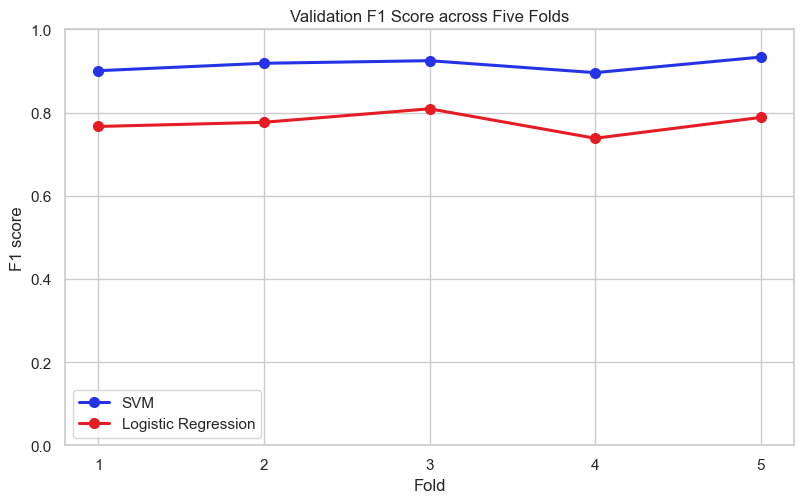

Saved fold F1 figure: D:\Project\Leeds\Msc Project\figure\figure_5_1_classical_models_fold_f1.png


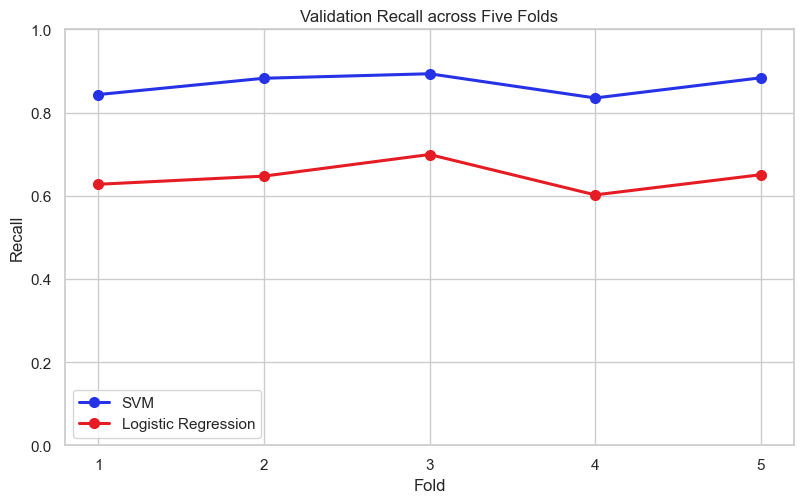

Saved fold recall figure: D:\Project\Leeds\Msc Project\figure\figure_5_2_classical_models_fold_recall.png


In [5]:
sns.set_theme(style='whitegrid')
model_order = ['SVM', 'Logistic Regression']
model_colours = {'SVM': '#2632E6', 'Logistic Regression': '#E51C23'}

fold_fig, fold_axis = plt.subplots(figsize=(8.2, 5.2))

for model_name in model_order:
    subset = fold_results[fold_results['model'] == model_name]
    fold_axis.plot(
        subset['fold'],
        subset['validation_f1'],
        marker='o',
        markersize=7,
        linewidth=2.2,
        color=model_colours[model_name],
        label=model_name,
    )
fold_axis.set_title('Validation F1 Score across Five Folds')
fold_axis.set_xlabel('Fold')
fold_axis.set_ylabel('F1 score')
fold_axis.set_xticks(range(1, N_SPLITS + 1))
fold_axis.set_ylim(0.00, 1.00)
fold_axis.legend()
fold_fig.tight_layout()
fold_fig.savefig(FOLD_F1_FIGURE_PATH, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved fold F1 figure: {FOLD_F1_FIGURE_PATH}')

recall_fig, recall_axis = plt.subplots(figsize=(8.2, 5.2))

for model_name in model_order:
    subset = fold_results[fold_results['model'] == model_name]
    recall_axis.plot(
        subset['fold'],
        subset['validation_recall'],
        marker='o',
        markersize=7,
        linewidth=2.2,
        color=model_colours[model_name],
        label=model_name,
    )
recall_axis.set_title('Validation Recall across Five Folds')
recall_axis.set_xlabel('Fold')
recall_axis.set_ylabel('Recall')
recall_axis.set_xticks(range(1, N_SPLITS + 1))
recall_axis.set_ylim(0.00, 1.00)
recall_axis.legend()
recall_fig.tight_layout()
recall_fig.savefig(RECALL_FIGURE_PATH, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved fold recall figure: {RECALL_FIGURE_PATH}')